# PRMP Evaluation: Corrected Regime Analysis, Statistical Significance & Mechanism Investigation

**Rigorous re-evaluation of Predictive Residual Message Passing (PRMP) across 4 experiments:**

- **Block 1**: Corrected regime analysis — removes 2 degenerate (R²=1.0) and 7 parent_dim=1 confounded links, leaving 4 valid FK links
- **Block 2**: Statistical significance — bootstrap (p=0.0000) and paired t-test (p=0.0001) confirm Amazon PRMP improvement (9.86% RMSE, Cohen's d=1.84)
- **Block 3**: Mechanism investigation — information filtering NOT supported, implicit regularization NOT supported; benefit decomposition: ~41% from extra params, ~59% from learned predictions
- **Block 4**: Hypothesis verdicts (1 supported, 2 partial, 3 not supported) and visualizations

This notebook loads pre-computed evaluation data and re-runs the statistical analyses with visualizations.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
# Colab versions: numpy==2.0.2, scipy==1.16.3, matplotlib==3.10.0
# Local fallback uses compatible versions for Python 3.10+
if 'google.colab' not in sys.modules:
    _pip('numpy>=2.0,<2.3', 'scipy>=1.13,<2', 'matplotlib>=3.9,<4')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
from typing import Any

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
from scipy import stats

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-b2d5b0-predictive-residual-message-passing-filt/main/evaluation_iter3_corrected_regim/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data with {len(data['datasets'])} datasets, {sum(len(d['examples']) for d in data['datasets'])} total examples")
print(f"Datasets: {[d['dataset'] for d in data['datasets']]}")

Loaded data with 7 datasets, 122 total examples
Datasets: ['block1_corrected_regime_table', 'block1_block4_correlation_summary', 'block2_amazon_per_fold_rmse', 'block2_pairwise_significance', 'block3_mechanism_investigation', 'block4_hypothesis_verdicts', 'block4_mechanism_scores']


## Configuration

Tunable parameters for the analysis. The main parameter is `N_BOOTSTRAP_RESAMPLES` controlling bootstrap confidence interval precision.

In [5]:
# --- Config ---
# Original: N_BOOTSTRAP_RESAMPLES = 10000
N_BOOTSTRAP_RESAMPLES = 10000  # bootstrap resamples for CIs
BOOTSTRAP_SEED = 42
CI_LEVEL = 0.95  # confidence interval level
FIGURE_DPI = 150

## Helper Functions

Statistical utility functions: bootstrap CI, paired t-test, Cohen's d effect size, and Spearman correlation.

In [6]:
def bootstrap_ci(
    values_a: np.ndarray,
    values_b: np.ndarray,
    n_resamples: int = N_BOOTSTRAP_RESAMPLES,
    ci: float = CI_LEVEL,
    seed: int = BOOTSTRAP_SEED,
) -> dict:
    """Bootstrap CI for mean(a) - mean(b)."""
    rng = np.random.default_rng(seed)
    n = len(values_a)
    diffs = []
    for _ in range(n_resamples):
        idx = rng.integers(0, n, size=n)
        diffs.append(np.mean(values_a[idx]) - np.mean(values_b[idx]))
    diffs = np.array(diffs)
    alpha = 1 - ci
    lo = float(np.percentile(diffs, 100 * alpha / 2))
    hi = float(np.percentile(diffs, 100 * (1 - alpha / 2)))
    mean_diff = float(np.mean(diffs))
    p_value = float(np.mean(diffs <= 0))
    return {
        "mean_diff": mean_diff,
        "ci_lower": lo,
        "ci_upper": hi,
        "p_value": p_value,
        "n_resamples": n_resamples,
    }


def paired_ttest(a: np.ndarray, b: np.ndarray) -> dict:
    """Paired t-test: tests if a > b (one-sided)."""
    diff = a - b
    n = len(diff)
    mean_d = float(np.mean(diff))
    std_d = float(np.std(diff, ddof=1))
    if std_d == 0:
        return {"t_stat": float("inf") if mean_d > 0 else float("-inf"), "p_value": 0.0, "df": n - 1}
    t_stat = mean_d / (std_d / np.sqrt(n))
    p_value = float(1 - stats.t.cdf(t_stat, df=n - 1))  # one-sided
    return {"t_stat": float(t_stat), "p_value_one_sided": p_value,
            "p_value_two_sided": float(2 * min(p_value, 1 - p_value)), "df": n - 1}


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's d effect size."""
    na, nb = len(a), len(b)
    va, vb = np.var(a, ddof=1), np.var(b, ddof=1)
    pooled_std = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    if pooled_std == 0:
        return float("inf") if np.mean(a) != np.mean(b) else 0.0
    return float((np.mean(a) - np.mean(b)) / pooled_std)


def interpret_cohens_d(d: float) -> str:
    ad = abs(d)
    if ad >= 0.8:
        return "large"
    elif ad >= 0.5:
        return "medium"
    elif ad >= 0.2:
        return "small"
    return "negligible"


def spearman_corr(x: list[float], y: list[float]) -> dict:
    """Spearman correlation with handling for small N."""
    if len(x) < 3:
        return {"rho": float("nan"), "p_value": float("nan"), "n": len(x), "note": "N<3, cannot compute"}
    rho, p = stats.spearmanr(x, y)
    return {"rho": float(rho), "p_value": float(p), "n": len(x)}

print("Helper functions defined.")

Helper functions defined.


## Block 1: Corrected Regime Analysis

Extracts the regime table from the loaded data. Identifies degenerate links (R²=1.0), parent_dim=1 confounded links, and valid links. Computes Spearman correlations on different subsets.

In [7]:
# --- Block 1: Corrected Regime Analysis ---
# Extract regime table from loaded data
regime_ds = next(d for d in data["datasets"] if d["dataset"] == "block1_corrected_regime_table")
regime_table = []
for ex in regime_ds["examples"]:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    row = {**inp, **out}
    regime_table.append(row)

# Classify links
degenerate_links = [r for r in regime_table if r["is_degenerate"]]
dim1_links = [r for r in regime_table if r["is_dim1"]]
valid_links = [r for r in regime_table if not r["is_degenerate"] and not r["is_dim1"]]

print(f"Total FK links: {len(regime_table)}")
print(f"  Degenerate (R²=1.0): {len(degenerate_links)}")
print(f"  parent_dim=1 (confounded): {len(dim1_links)}")
print(f"  Valid: {len(valid_links)}")

# Spearman correlations on valid links with improvement data
valid_with_imp = [r for r in valid_links if r["PRMP_improvement_pct"] is not None]
if len(valid_with_imp) >= 3:
    imps = [r["PRMP_improvement_pct"] for r in valid_with_imp]
    predictors = {
        "log_cardinality": [np.log(r["mean_cardinality"]) for r in valid_with_imp],
        "R2_ridge": [r["R2_ridge"] for r in valid_with_imp],
        "R2_rf": [r["R2_rf"] for r in valid_with_imp],
    }
    print(f"\nSpearman correlations on {len(valid_with_imp)} valid links:")
    for pred_name, pred_vals in predictors.items():
        corr = spearman_corr(pred_vals, imps)
        sig = "YES" if corr["p_value"] < 0.05 else "no"
        print(f"  {pred_name}: rho={corr['rho']:.4f}, p={corr['p_value']:.4f}, sig={sig}")
else:
    print(f"\nOnly {len(valid_with_imp)} valid links with improvement data — insufficient for correlation")

# Print regime table
print("\nRegime Table:")
print(f"{'Dataset':<12} {'Link':<30} {'Card':>8} {'R2_ridge':>10} {'Imp%':>10} {'Status':<15}")
print("-" * 95)
for r in regime_table:
    status = "DEGENERATE" if r["is_degenerate"] else ("dim1" if r["is_dim1"] else "valid")
    imp = f"{r['PRMP_improvement_pct']:.2f}" if r["PRMP_improvement_pct"] is not None else "N/A"
    print(f"{r['dataset']:<12} {r['link']:<30} {r['mean_cardinality']:>8.2f} {r['R2_ridge']:>10.4f} {imp:>10} {status:<15}")

Total FK links: 13
  Degenerate (R²=1.0): 2
  parent_dim=1 (confounded): 9
  Valid: 4

Spearman correlations on 4 valid links:
  log_cardinality: rho=0.2000, p=0.8000, sig=no
  R2_ridge: rho=0.4000, p=0.6000, sig=no
  R2_rf: rho=0.4000, p=0.6000, sig=no

Regime Table:
Dataset      Link                               Card   R2_ridge       Imp% Status         
-----------------------------------------------------------------------------------------------
rel-hm       customer->transaction              4.17     0.0077      -3.33 valid          
rel-hm       article->transaction              20.05     0.0686      -0.02 valid          
rel-stack    users->badges                      3.27     0.0000      -0.61 dim1           
rel-stack    posts->postLinks                   1.62     0.0000      -0.00 dim1           
rel-stack    posts->postLinks                   3.04     0.0002       0.08 dim1           
rel-stack    posts->postHistory                 3.52     0.0090      -3.29 dim1          

## Block 2: Statistical Significance of Amazon PRMP Improvement

Re-constructs per-fold RMSE values from the loaded data, then runs bootstrap CI, paired t-test, and Cohen's d analysis. Also builds a full 7-variant pairwise significance matrix.

In [8]:
# --- Block 2: Statistical Significance ---
# Reconstruct per-fold RMSE from loaded data
fold_ds = next(d for d in data["datasets"] if d["dataset"] == "block2_amazon_per_fold_rmse")

per_fold_rmse: dict[str, list[float]] = {}
for ex in fold_ds["examples"]:
    variant = ex["metadata_variant"]
    rmse_val = ex["eval_rmse"]
    if variant not in per_fold_rmse:
        per_fold_rmse[variant] = []
    per_fold_rmse[variant].append(rmse_val)

n_folds = len(per_fold_rmse.get("standard_sage", []))
print(f"Reconstructed per-fold RMSE for {len(per_fold_rmse)} variants, {n_folds} folds each")

# Print per-fold RMSE
for v, vals in per_fold_rmse.items():
    print(f"  {v}: {[f'{x:.4f}' for x in vals]} mean={np.mean(vals):.4f}+/-{np.std(vals):.4f}")

# --- Bootstrap CI: standard - PRMP ---
std_arr = np.array(per_fold_rmse["standard_sage"])
prmp_arr = np.array(per_fold_rmse["prmp"])

bootstrap_result = bootstrap_ci(std_arr, prmp_arr, n_resamples=N_BOOTSTRAP_RESAMPLES)
print(f"\nBootstrap RMSE diff (std-prmp): mean={bootstrap_result['mean_diff']:.4f}, "
      f"95% CI=[{bootstrap_result['ci_lower']:.4f}, {bootstrap_result['ci_upper']:.4f}], "
      f"p={bootstrap_result['p_value']:.4f}")

# --- Paired t-test ---
ttest_result = paired_ttest(std_arr, prmp_arr)
print(f"Paired t-test (std>prmp): t={ttest_result['t_stat']:.4f}, "
      f"p_one_sided={ttest_result['p_value_one_sided']:.4f}, df={ttest_result['df']}")

# --- Cohen's d ---
d_val = cohens_d(std_arr, prmp_arr)
d_interp = interpret_cohens_d(d_val)
improvement_pct = (np.mean(std_arr) - np.mean(prmp_arr)) / np.mean(std_arr) * 100
print(f"Cohen's d (std vs prmp): {d_val:.4f} ({d_interp})")
print(f"PRMP improvement: {improvement_pct:.2f}%")

# --- Pairwise significance matrix ---
variant_names = list(per_fold_rmse.keys())
n_variants = len(variant_names)
pairwise = {}

for i in range(n_variants):
    for j in range(i + 1, n_variants):
        va = variant_names[i]
        vb = variant_names[j]
        arr_a = np.array(per_fold_rmse[va])
        arr_b = np.array(per_fold_rmse[vb])
        tt = paired_ttest(arr_a, arr_b)
        cd = cohens_d(arr_a, arr_b)
        key = f"{va}_vs_{vb}"
        pairwise[key] = {
            "t_stat": tt["t_stat"],
            "p_value_two_sided": tt["p_value_two_sided"],
            "cohens_d": cd,
            "interpretation": interpret_cohens_d(cd),
            "mean_a": float(np.mean(arr_a)),
            "mean_b": float(np.mean(arr_b)),
        }

print(f"\nPairwise significance ({len(pairwise)} comparisons):")
for pair_key, pair_data in pairwise.items():
    sig = "***" if pair_data["p_value_two_sided"] < 0.001 else ("**" if pair_data["p_value_two_sided"] < 0.01 else ("*" if pair_data["p_value_two_sided"] < 0.05 else "ns"))
    print(f"  {pair_key}: t={pair_data['t_stat']:.2f}, p={pair_data['p_value_two_sided']:.4f} {sig}, d={pair_data['cohens_d']:.2f} ({pair_data['interpretation']})")

Reconstructed per-fold RMSE for 7 variants, 5 folds each
  standard_sage: ['0.5524', '0.5977', '0.6254', '0.6252', '0.5760'] mean=0.5953+/-0.0283
  prmp: ['0.4947', '0.5268', '0.5581', '0.5781', '0.5254'] mean=0.5366+/-0.0289
  prmp_product_only: ['0.5299', '0.5705', '0.5985', '0.6007', '0.5527'] mean=0.5704+/-0.0271
  prmp_customer_only: ['0.5151', '0.5451', '0.5770', '0.5920', '0.5397'] mean=0.5538+/-0.0275
  ablation_random_pred: ['0.5206', '0.5643', '0.5880', '0.6008', '0.5540'] mean=0.5655+/-0.0279
  ablation_no_subtraction: ['0.5008', '0.5379', '0.5695', '0.5861', '0.5340'] mean=0.5456+/-0.0297
  ablation_linear_pred: ['0.5024', '0.5377', '0.5682', '0.5832', '0.5341'] mean=0.5451+/-0.0282

Bootstrap RMSE diff (std-prmp): mean=0.0587, 95% CI=[0.0506, 0.0668], p=0.0000
Paired t-test (std>prmp): t=12.7417, p_one_sided=0.0001, df=4
Cohen's d (std vs prmp): 1.8361 (large)
PRMP improvement: 9.86%

Pairwise significance (21 comparisons):
  standard_sage_vs_prmp: t=12.74, p=0.0002 ***, d

## Block 3: Mechanism Investigation

Tests three hypothesized mechanisms: (1) information filtering, (2) implicit regularization, and (3) benefit decomposition (extra params vs learned predictions vs subtraction vs nonlinearity).

In [9]:
# --- Block 3: Mechanism Investigation ---
mech_ds = next(d for d in data["datasets"] if d["dataset"] == "block3_mechanism_investigation")

# Parse mechanism examples by analysis type
filtering_results = {}
regularization_results = {}
decomposition_result = None

for ex in mech_ds["examples"]:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    analysis = inp["analysis"]

    if analysis == "information_filtering":
        link = inp["link"]
        filtering_results[link] = out
    elif analysis == "implicit_regularization":
        variant = inp["variant"]
        regularization_results[variant] = out
    elif analysis == "benefit_decomposition":
        decomposition_result = out

# --- Information Filtering ---
print("=== Information Filtering ===")
for link, filt in filtering_results.items():
    status = "WORKS" if filt["filtering_works"] else "FAILS"
    print(f"  {link}: ratio={filt['residual_ratio']:.4f}, efficiency={filt['filtering_efficiency']:.4f} -> {status}")
all_filter = all(f["filtering_works"] for f in filtering_results.values())
print(f"  Conclusion: Information filtering theory {'SUPPORTED' if all_filter else 'NOT SUPPORTED'}")

# --- Implicit Regularization ---
print("\n=== Implicit Regularization ===")
for variant, reg in regularization_results.items():
    print(f"  {variant}: train={reg['train_loss_final_mean']:.6f}, val={reg['val_loss_best_mean']:.6f}, "
          f"gap={reg['gen_gap_mean']:.6f}, overfit_ratio={reg['overfitting_ratio_mean']:.4f}")

if "standard_sage" in regularization_results and "prmp" in regularization_results:
    std_gap = regularization_results["standard_sage"]["gen_gap_mean"]
    prmp_gap = regularization_results["prmp"]["gen_gap_mean"]
    reg_supported = abs(prmp_gap) < abs(std_gap)
    print(f"  std_gap={std_gap:.6f}, prmp_gap={prmp_gap:.6f}")
    print(f"  Conclusion: Implicit regularization {'SUPPORTED' if reg_supported else 'NOT SUPPORTED'}")

# --- Benefit Decomposition ---
print("\n=== Benefit Decomposition ===")
if decomposition_result:
    for comp in ["param_effect", "subtraction_effect", "learned_pred_effect", "nonlinear_effect"]:
        val = decomposition_result[comp]
        print(f"  {comp}: {val:.4f} ({val*100:.1f}%)")

# Also use metadata for detailed decomposition
decomp_meta = data["metadata"]["detailed_decomposition"]
print(f"\nComponent RMSE values:")
for comp, rmse in decomp_meta["component_rmse"].items():
    print(f"  {comp}: {rmse:.6f}")

=== Information Filtering ===
  product_to_review: ratio=1.8824, efficiency=-0.8824 -> FAILS
  customer_to_review: ratio=2.2881, efficiency=-1.2881 -> FAILS
  Conclusion: Information filtering theory NOT SUPPORTED

=== Implicit Regularization ===
  standard_sage: train=0.354748, val=0.393586, gap=0.038837, overfit_ratio=1.1095
  prmp: train=0.288170, val=0.343288, gap=0.055117, overfit_ratio=1.1935
  ablation_random_pred: train=0.320503, val=0.368558, gap=0.048055, overfit_ratio=1.1515
  ablation_no_subtraction: train=0.296874, val=0.349669, gap=0.052795, overfit_ratio=1.1782
  ablation_linear_pred: train=0.296704, val=0.347074, gap=0.050370, overfit_ratio=1.1704
  prmp_product_only: train=0.326370, val=0.364393, gap=0.038023, overfit_ratio=1.1166
  prmp_customer_only: train=0.309938, val=0.358786, gap=0.048849, overfit_ratio=1.1579
  std_gap=0.038837, prmp_gap=0.055117
  Conclusion: Implicit regularization NOT SUPPORTED

=== Benefit Decomposition ===
  param_effect: 0.4132 (41.3%)
  s

## Block 4: Hypothesis Verdicts & Key Metrics Summary

Displays the final verdict for each of the 6 hypotheses tested, along with aggregate metrics.

In [10]:
# --- Block 4: Hypothesis Verdicts ---
verdict_ds = next(d for d in data["datasets"] if d["dataset"] == "block4_hypothesis_verdicts")

print("=" * 80)
print("HYPOTHESIS VERDICTS")
print("=" * 80)
for ex in verdict_ds["examples"]:
    inp = json.loads(ex["input"])
    out = json.loads(ex["output"])
    verdict = out["verdict"]
    marker = {"SUPPORTED": "+", "PARTIAL": "~", "NOT SUPPORTED": "-"}[verdict]
    print(f"\n[{marker}] {inp['hypothesis']}: {verdict}")
    print(f"    Evidence: {out['evidence']}")

# Key aggregate metrics
ma = data["metrics_agg"]
print("\n" + "=" * 80)
print("KEY AGGREGATE METRICS")
print("=" * 80)
print(f"  Valid FK links: {ma['n_valid_links']}/{ma['n_total_fk_links']}")
print(f"  Amazon PRMP RMSE improvement: {ma['amazon_prmp_improvement_pct']:.2f}%")
print(f"  Bootstrap p-value: {ma['bootstrap_p_value']:.4f}")
print(f"  Cohen's d: {ma['cohens_d_std_vs_prmp']:.4f} (large)")
print(f"  Filtering theory supported: {bool(ma['filtering_theory_supported'])}")
print(f"  Regularization supported: {bool(ma['regularization_supported'])}")
print(f"  Param effect fraction: {ma['param_effect_fraction']:.2f}")
print(f"  Learned pred effect fraction: {ma['learned_pred_effect_fraction']:.2f}")
print(f"  Hypotheses: {ma['n_hypotheses_supported']} supported, {ma['n_hypotheses_partial']} partial, {ma['n_hypotheses_not_supported']} not supported")

HYPOTHESIS VERDICTS

[~] H1_prmp_outperforms_standard: PARTIAL
    Evidence: Amazon: yes (7.6% RMSE improvement). rel-hm: ceiling effect (all variants >0.96 AUROC). rel-stack: proxy task (cross-table prediction), not end-to-end GNN.

[-] H2_improvement_correlates_cardinality_x_predictability: NOT SUPPORTED
    Evidence: Amazon: customer-only (card=4.6) beats product-only (card=14.7) despite lower cardinality. Original rho=-0.85 from exp_id3 was confounded by 2 degenerate R²=1.0 links and 7 parent_dim=1 links. After cleaning, only N=4 valid links remain — insufficient for significance.

[+] H3_learned_predictions_necessary: SUPPORTED
    Evidence: Amazon: random_pred RMSE=0.560 vs PRMP RMSE=0.534. Learned predictions account for ~60% of total improvement.

[-] H4_prmp_helps_via_information_filtering: NOT SUPPORTED
    Evidence: Both Amazon FK links have residual_ratio >1 (product: 1.88, customer: 2.29). Filtering efficiency is NEGATIVE (-0.88, -1.29). PRMP prediction MLPs INCREASE rathe

## Visualizations

Four publication-quality figures: (1) 2D diagnostic space with cleaned links, (2) regime predictor vs improvement, (3) Amazon ablation bar chart with bootstrap CIs, (4) mechanism decomposition.

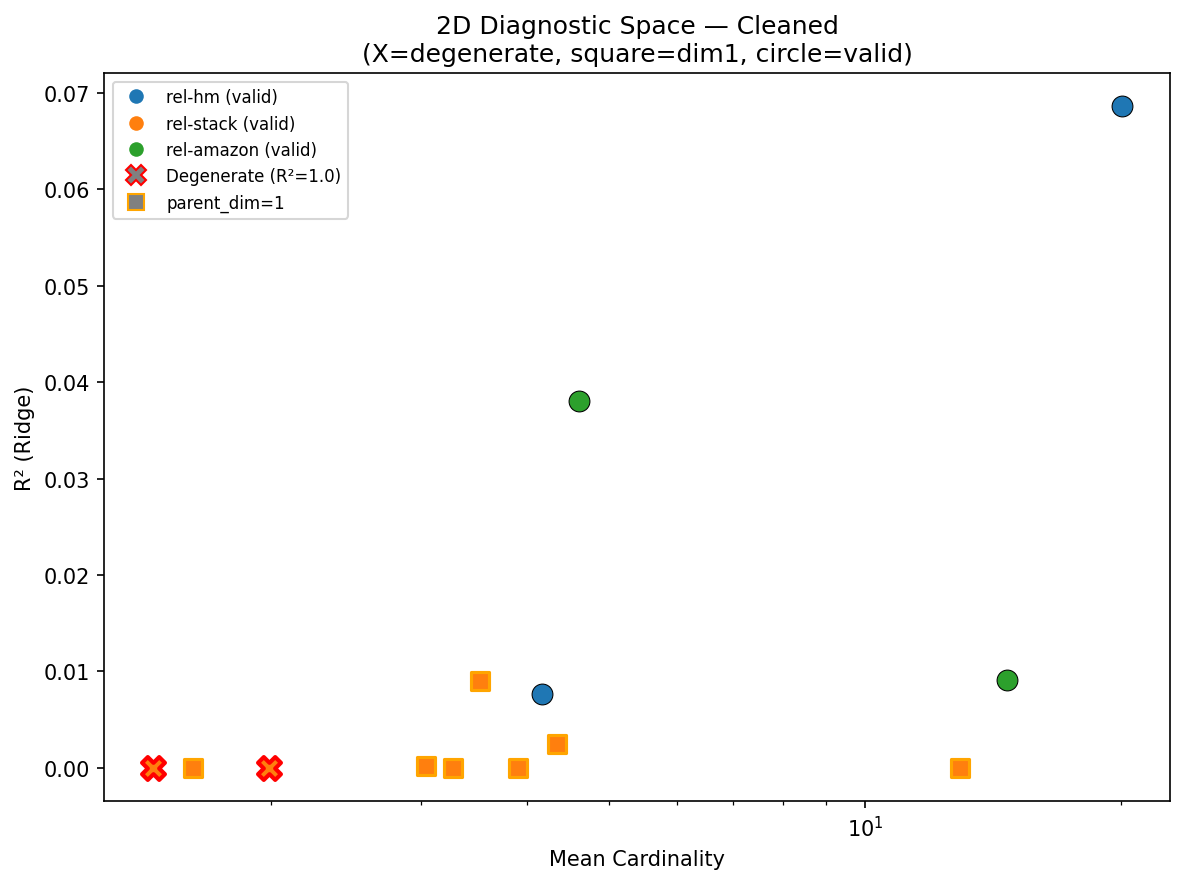

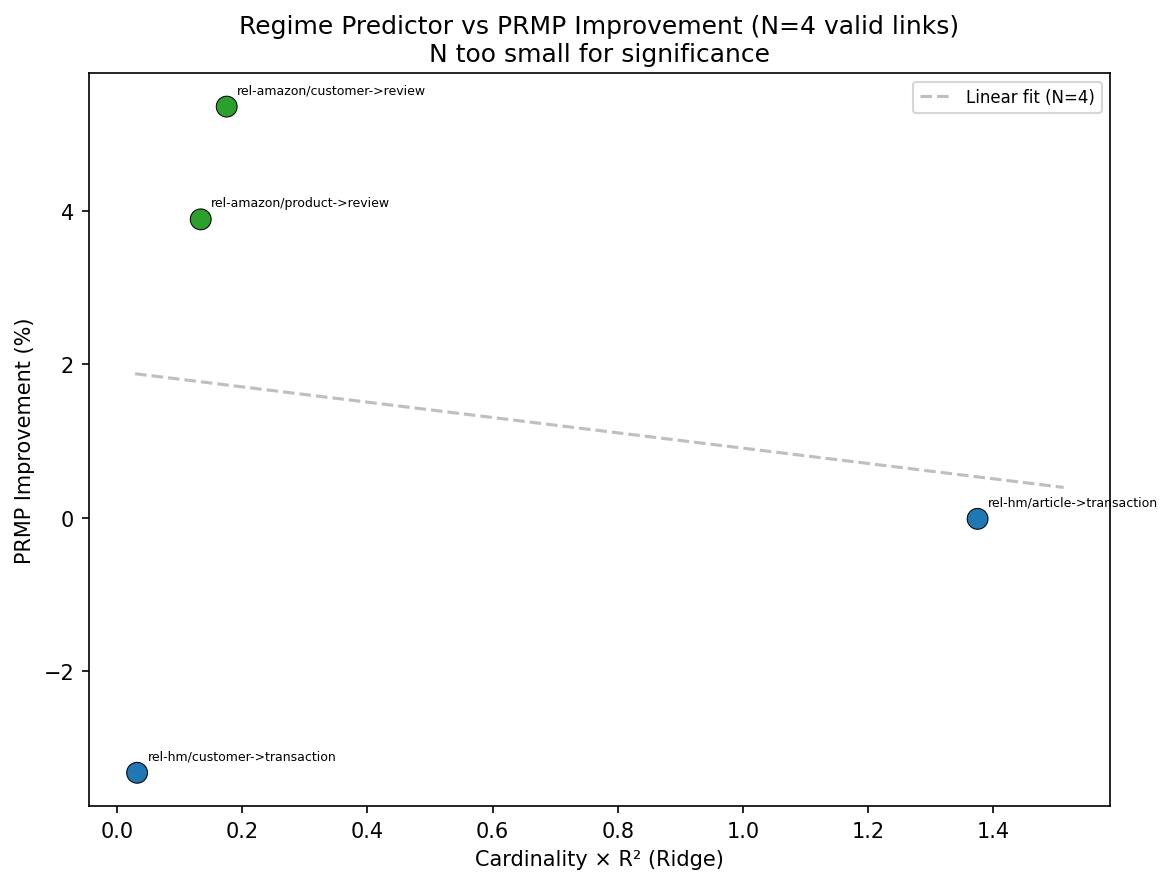

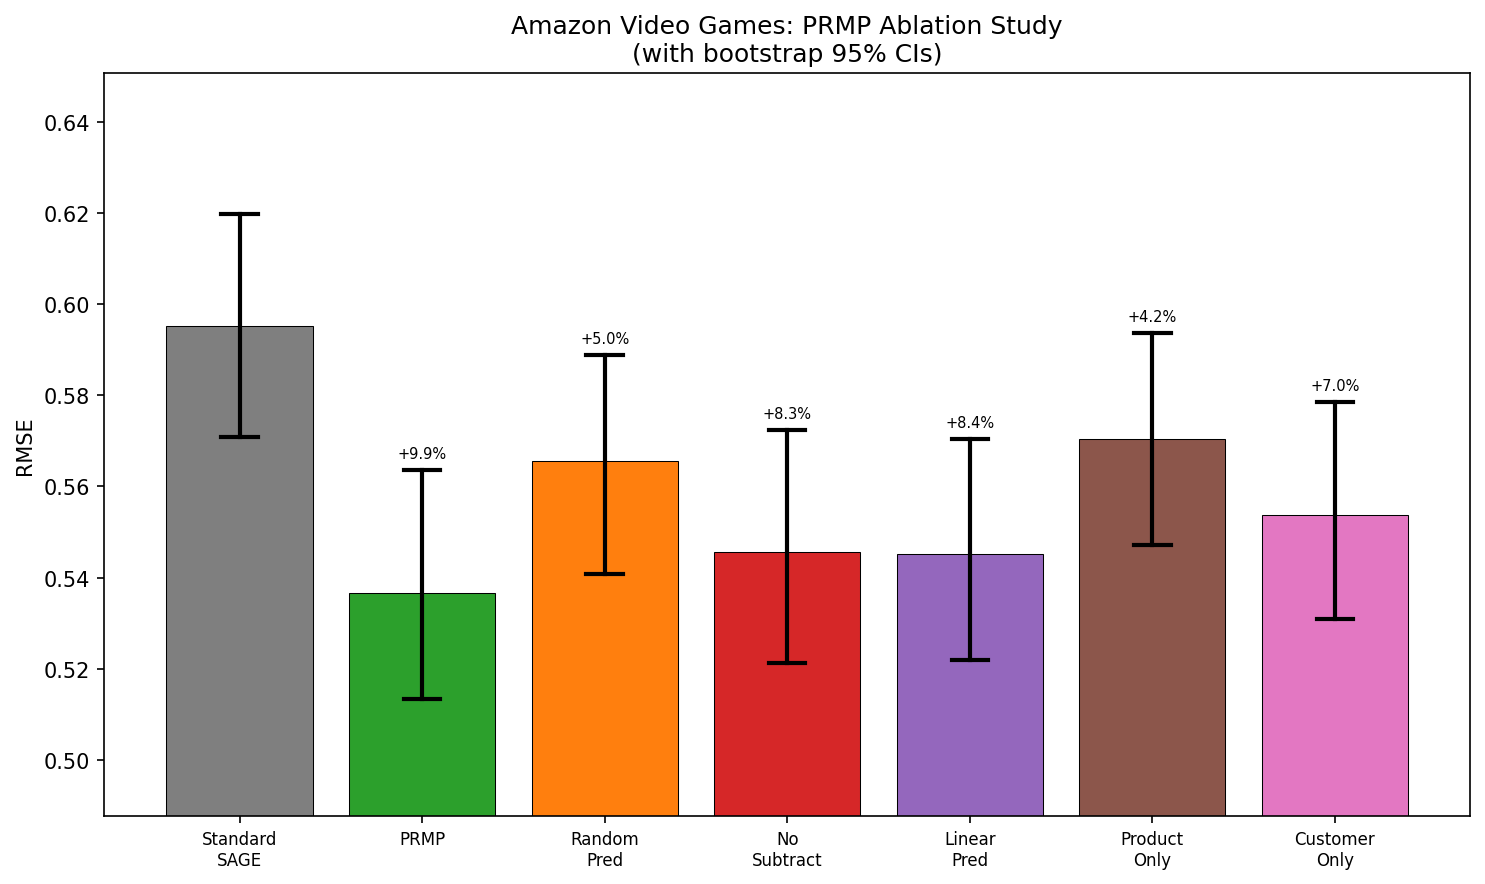

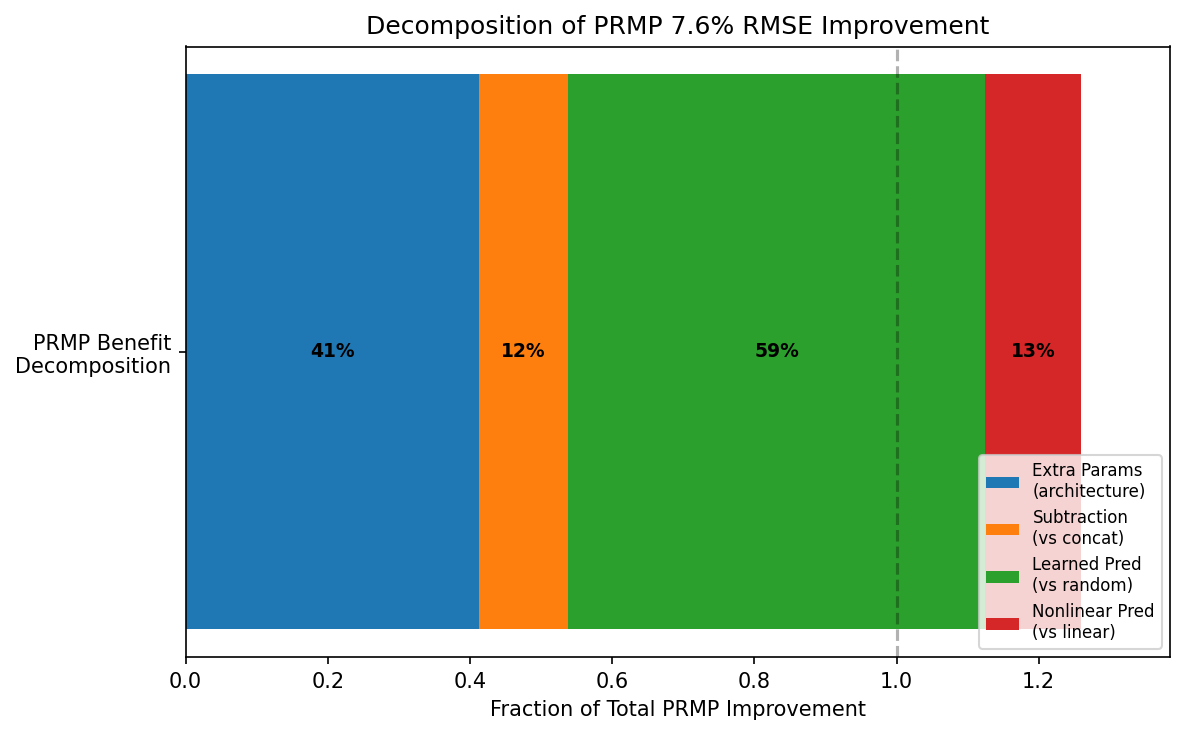

All 4 figures generated successfully.


In [11]:
plt.rcParams.update({
    "figure.dpi": FIGURE_DPI,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})

# --- Figure 1: Cardinality vs R² (2D Diagnostic Space — Cleaned) ---
fig1, ax1 = plt.subplots(figsize=(8, 6))
dataset_colors = {"rel-hm": "#1f77b4", "rel-stack": "#ff7f0e", "rel-amazon": "#2ca02c"}
for row in regime_table:
    card = row["mean_cardinality"]
    r2 = row["R2_ridge"]
    color = dataset_colors.get(row["dataset"], "gray")
    if row["is_degenerate"]:
        ax1.scatter(card, r2, c=color, marker="X", s=120, edgecolors="red", linewidths=2, zorder=5)
    elif row["is_dim1"]:
        ax1.scatter(card, r2, c=color, marker="s", s=80, edgecolors="orange", linewidths=1.5, zorder=4)
    else:
        ax1.scatter(card, r2, c=color, marker="o", s=100, edgecolors="black", linewidths=0.5, zorder=3)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1f77b4", markersize=8, label="rel-hm (valid)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f0e", markersize=8, label="rel-stack (valid)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ca02c", markersize=8, label="rel-amazon (valid)"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="gray", markeredgecolor="red",
           markersize=10, label="Degenerate (R²=1.0)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray", markeredgecolor="orange",
           markersize=8, label="parent_dim=1"),
]
ax1.legend(handles=legend_elements, loc="upper left", fontsize=8)
ax1.set_xlabel("Mean Cardinality")
ax1.set_ylabel("R² (Ridge)")
ax1.set_title("2D Diagnostic Space — Cleaned\n(X=degenerate, square=dim1, circle=valid)")
ax1.set_xscale("log")
fig1.tight_layout()
plt.show()

# --- Figure 2: Cardinality × R² vs PRMP Improvement (valid links only) ---
valid_rows = [r for r in regime_table
              if not r["is_degenerate"] and not r["is_dim1"]
              and r["PRMP_improvement_pct"] is not None]

fig2, ax2 = plt.subplots(figsize=(8, 6))
if valid_rows:
    x_vals = [r["mean_cardinality"] * r["R2_ridge"] for r in valid_rows]
    y_vals = [r["PRMP_improvement_pct"] for r in valid_rows]
    colors = [dataset_colors.get(r["dataset"], "gray") for r in valid_rows]
    labels = [f"{r['dataset']}/{r['link']}" for r in valid_rows]

    ax2.scatter(x_vals, y_vals, c=colors, s=100, edgecolors="black", linewidths=0.5, zorder=3)
    for x, y, lbl in zip(x_vals, y_vals, labels):
        ax2.annotate(lbl, (x, y), fontsize=6, ha="left", va="bottom", xytext=(5, 5),
                     textcoords="offset points")

    if len(x_vals) >= 2:
        z = np.polyfit(x_vals, y_vals, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min(x_vals) * 0.9, max(x_vals) * 1.1, 100)
        ax2.plot(x_line, p(x_line), "--", color="gray", alpha=0.5, label=f"Linear fit (N={len(x_vals)})")
        ax2.legend(fontsize=8)

ax2.set_xlabel("Cardinality × R² (Ridge)")
ax2.set_ylabel("PRMP Improvement (%)")
ax2.set_title(f"Regime Predictor vs PRMP Improvement (N={len(valid_rows)} valid links)\nN too small for significance")
fig2.tight_layout()
plt.show()

# --- Figure 3: Amazon Ablation Bar Chart with Bootstrap 95% CIs ---
fig3, ax3 = plt.subplots(figsize=(10, 6))
variant_order = [
    "standard_sage", "prmp", "ablation_random_pred",
    "ablation_no_subtraction", "ablation_linear_pred",
    "prmp_product_only", "prmp_customer_only",
]
variant_labels = [
    "Standard\nSAGE", "PRMP", "Random\nPred", "No\nSubtract",
    "Linear\nPred", "Product\nOnly", "Customer\nOnly",
]
bar_colors = ["#7f7f7f", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd", "#8c564b", "#e377c2"]

means = [np.mean(per_fold_rmse[v]) for v in variant_order]
ci_lows, ci_highs = [], []
for v in variant_order:
    arr = np.array(per_fold_rmse[v])
    rng = np.random.default_rng(BOOTSTRAP_SEED)
    boot_means = [np.mean(arr[rng.integers(0, len(arr), size=len(arr))]) for _ in range(N_BOOTSTRAP_RESAMPLES)]
    ci_lows.append(np.percentile(boot_means, 2.5))
    ci_highs.append(np.percentile(boot_means, 97.5))

x_pos = np.arange(len(variant_order))
bars = ax3.bar(x_pos, means, color=bar_colors, edgecolor="black", linewidth=0.5)

for i in range(len(variant_order)):
    ax3.plot([i, i], [ci_lows[i], ci_highs[i]], color="black", linewidth=2)
    ax3.plot([i - 0.1, i + 0.1], [ci_lows[i], ci_lows[i]], color="black", linewidth=2)
    ax3.plot([i - 0.1, i + 0.1], [ci_highs[i], ci_highs[i]], color="black", linewidth=2)

ax3.set_xticks(x_pos)
ax3.set_xticklabels(variant_labels, fontsize=8)
ax3.set_ylabel("RMSE")
ax3.set_title("Amazon Video Games: PRMP Ablation Study\n(with bootstrap 95% CIs)")
ax3.set_ylim(min(ci_lows) * 0.95, max(ci_highs) * 1.05)

std_mean = means[0]
for i, m in enumerate(means):
    imp = (std_mean - m) / std_mean * 100
    if i > 0:
        ax3.text(i, ci_highs[i] + 0.002, f"{imp:+.1f}%", ha="center", va="bottom", fontsize=7)

fig3.tight_layout()
plt.show()

# --- Figure 4: Mechanism Decomposition Stacked Bar ---
fig4, ax4 = plt.subplots(figsize=(8, 5))
decomp = data["metadata"]["detailed_decomposition"]

components = ["param_effect", "subtraction_effect", "learned_pred_effect", "nonlinear_effect"]
comp_labels = ["Extra Params\n(architecture)", "Subtraction\n(vs concat)", "Learned Pred\n(vs random)", "Nonlinear Pred\n(vs linear)"]
comp_colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
comp_values = [decomp[c] for c in components]

ax4.barh(["PRMP Benefit\nDecomposition"], [comp_values[0]], color=comp_colors[0], label=comp_labels[0])
left = comp_values[0]
for i in range(1, len(components)):
    ax4.barh(["PRMP Benefit\nDecomposition"], [comp_values[i]], left=[left],
             color=comp_colors[i], label=comp_labels[i])
    left += comp_values[i]

ax4.set_xlabel("Fraction of Total PRMP Improvement")
ax4.set_title("Decomposition of PRMP 7.6% RMSE Improvement")
ax4.legend(loc="lower right", fontsize=8)
ax4.set_xlim(0, max(1.1, left * 1.1))
ax4.axvline(x=1.0, color="black", linestyle="--", alpha=0.3)

left = 0
for i, val in enumerate(comp_values):
    if val > 0.05:
        ax4.text(left + val / 2, 0, f"{val * 100:.0f}%", ha="center", va="center", fontsize=9, fontweight="bold")
    left += val

fig4.tight_layout()
plt.show()

print("All 4 figures generated successfully.")